# Feature Engineering

In [1055]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [1056]:
# PATH DEFINITIONS
BASE_DIR = Path().resolve().parent

DATA_DIR = BASE_DIR / "data"
CLEAN_DATA_DIR = DATA_DIR / "data_clean"

In [1057]:
# NOT THE IDEAL, BUT IT WORKS, AFTER, SEARCH FOR ANOTHER APPROACH ON cleaning.py

df_clean = pd.read_csv(CLEAN_DATA_DIR / "train_clean.csv", keep_default_na=False, na_values=[""])

## Classification

In [1058]:
df_clean.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE,HASGARAGE,HASPOOL
0,1,60,RL,65.0,8450.0,PAVE,NA,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706.0,UNF,0.0,150.0,856.0,GASA,EX,Y,SBRKR,856.0,854.0,0.0,1710.0,1,0,2,1,3,1,GD,8,TYP,0,NA,ATTCHD,RFN,2,548.0,TA,TA,Y,0.0,61.0,0.0,0.0,0.0,NA,NA,0,2,2008,WD,NORMAL,208500.0,True,False
1,2,20,RL,80.0,9600.0,PAVE,NA,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,None,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978.0,UNF,0.0,284.0,1262.0,GASA,EX,Y,SBRKR,1262.0,0.0,0.0,1262.0,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,RFN,2,460.0,TA,TA,Y,298.0,0.0,0.0,0.0,0.0,NA,NA,0,5,2007,WD,NORMAL,181500.0,True,False
2,3,60,RL,68.0,11250.0,PAVE,NA,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486.0,UNF,0.0,434.0,920.0,GASA,EX,Y,SBRKR,920.0,866.0,0.0,1786.0,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,RFN,2,608.0,TA,TA,Y,0.0,42.0,0.0,0.0,0.0,NA,NA,0,9,2008,WD,NORMAL,223500.0,True,False
3,4,70,RL,60.0,9550.0,PAVE,NA,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,None,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216.0,UNF,0.0,540.0,756.0,GASA,GD,Y,SBRKR,961.0,756.0,0.0,1717.0,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,UNF,3,642.0,TA,TA,Y,0.0,35.0,272.0,0.0,0.0,NA,NA,0,2,2006,WD,ABNORML,140000.0,True,False
4,5,60,RL,84.0,14260.0,PAVE,NA,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655.0,UNF,0.0,490.0,1145.0,GASA,EX,Y,SBRKR,1145.0,1053.0,0.0,2198.0,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,RFN,3,836.0,TA,TA,Y,192.0,84.0,0.0,0.0,0.0,NA,NA,0,12,2008,WD,NORMAL,250000.0,True,False


In [1059]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1412 non-null   int64  
 1   MSSUBCLASS     1412 non-null   int64  
 2   MSZONING       1412 non-null   str    
 3   LOTFRONTAGE    1412 non-null   float64
 4   LOTAREA        1412 non-null   float64
 5   STREET         1412 non-null   str    
 6   ALLEY          1412 non-null   str    
 7   LOTSHAPE       1412 non-null   str    
 8   LANDCONTOUR    1412 non-null   str    
 9   UTILITIES      1412 non-null   str    
 10  LOTCONFIG      1412 non-null   str    
 11  LANDSLOPE      1412 non-null   str    
 12  NEIGHBORHOOD   1412 non-null   str    
 13  CONDITION1     1412 non-null   str    
 14  CONDITION2     1412 non-null   str    
 15  BLDGTYPE       1412 non-null   str    
 16  HOUSESTYLE     1412 non-null   str    
 17  OVERALLQUAL    1412 non-null   int64  
 18  OVERALLCOND    1412

In [1060]:
qual_ord = [
    "LOTSHAPE", "UTILITIES", "LANDSLOPE", "OVERALLQUAL",
    "OVERALLCOND", "EXTERQUAL", "EXTERCOND", "BSMTQUAL",
    "BSMTCOND", "BSMTEXPOSURE", "BSMTFINTYPE1", "BSMTFINTYPE2",
    "HEATINGQC", "ELECTRICAL", "KITCHENQUAL", "FUNCTIONAL",
    "FIREPLACEQU", "GARAGEFINISH", "GARAGEQUAL", "GARAGECOND",
    "PAVEDDRIVE", "FENCE"
]

qual_nom = [
    "MSSUBCLASS", "MSZONING", "STREET", "ALLEY", "LANDCONTOUR",
    "LOTCONFIG", "NEIGHBORHOOD", "CONDITION1", "CONDITION2",
    "BLDGTYPE", "HOUSESTYLE", "ROOFSTYLE", "ROOFMATL",
    "EXTERIOR1ST", "EXTERIOR2ND", "MASVNRTYPE", "FOUNDATION",
    "HEATING", "CENTRALAIR", "GARAGETYPE", "MISCFEATURE",
    "SALETYPE", "SALECONDITION"
]


quant_disc = df_clean.select_dtypes(include='int64').drop(
    columns=["ID"] + qual_ord + qual_nom, errors="ignore"
)

# SALEPRICE is the target, not a feature: kept out of quant_cont so it never
# gets swept into the generic feature-treatment loops below (see target
# transformation cell in the Quantitative Continuos section).
quant_cont = list(df_clean.select_dtypes(include='float64').drop(columns=["SALEPRICE"], errors="ignore").columns)
quant_bool = list(df_clean.select_dtypes(include='bool').columns)


In [1061]:
df_qual_ord = df_clean.copy()

for col in qual_ord:
    print(df_qual_ord[col].value_counts().sort_index(ascending=False))
    print()

LOTSHAPE
REG    886
IR3     10
IR2     40
IR1    476
Name: count, dtype: int64

UTILITIES
NOSEWA       1
ALLPUB    1411
Name: count, dtype: int64

LANDSLOPE
SEV      13
MOD      64
GTL    1335
Name: count, dtype: int64

OVERALLQUAL
10     17
9      43
8     166
7     313
6     371
5     381
4     103
3      14
2       3
1       1
Name: count, dtype: int64

OVERALLCOND
9     22
8     72
7    200
6    248
5    792
4     52
3     20
2      5
1      1
Name: count, dtype: int64

EXTERQUAL
TA    871
GD    478
FA     12
EX     51
Name: count, dtype: int64

EXTERCOND
TA    1239
PO       1
GD     145
FA      24
EX       3
Name: count, dtype: int64

BSMTQUAL
TA    648
GD    609
FA     35
EX    120
Name: count, dtype: int64

BSMTCOND
TA    1301
PO       2
GD      64
FA      45
Name: count, dtype: int64

BSMTEXPOSURE
NO    944
MN    114
GD    133
AV    221
Name: count, dtype: int64

BSMTFINTYPE1
UNF    426
REC    132
LWQ     74
GLQ    412
BLQ    148
ALQ    220
Name: count, dtype: int64

BSMTFINTYP

In [1062]:
columns_to_drop = ["UTILITIES"]
columns_to_add = []

# GRADES 1-10
mapping_1_10_grades = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: 2,
    8: 3,
    9: 3,
    10: 3,
}
df_qual_ord["OVERALLCOND"] = df_qual_ord["OVERALLCOND"].map(mapping_1_10_grades)
df_qual_ord["OVERALLQUAL"] = df_qual_ord["OVERALLQUAL"].map(mapping_1_10_grades)

# FIVE QUALITIES
map_qual_5 = {
    "NA": 0,
    "PO": 0,
    "FA": 2,
    "TA": 2,
    "GD": 3,
    "EX": 3,
}
df_qual_ord["EXTERQUAL"] = df_qual_ord["EXTERQUAL"].map(map_qual_5)
df_qual_ord["EXTERCOND"] = df_qual_ord["EXTERCOND"].map(map_qual_5)
df_qual_ord["HEATINGQC"] = df_qual_ord["HEATINGQC"].map(map_qual_5)
df_qual_ord["KITCHENQUAL"] = df_qual_ord["KITCHENQUAL"].map(map_qual_5)

# SIX QUALITIES
map_qual_6 = {"NA": 0, "PO": 0, "FA": 2, "TA": 2, "GD": 3, "EX": 3}

df_qual_ord["BSMTQUAL"] = df_qual_ord["BSMTQUAL"].map(map_qual_6)
df_qual_ord["BSMTCOND"] = df_qual_ord["BSMTCOND"].map(map_qual_6)
df_qual_ord["FIREPLACEQU"] = df_qual_ord["FIREPLACEQU"].map(map_qual_6)
df_qual_ord["GARAGEQUAL"] = df_qual_ord["GARAGEQUAL"].map(map_qual_6)
df_qual_ord["GARAGECOND"] = df_qual_ord["GARAGECOND"].map(map_qual_6)

# BSMT TYPE
map_bsmt_fin = {
    "NA": 0,
    "UNF": 1,
    "LWQ": 2,
    "REC": 2,
    "BLQ": 2,
    "ALQ": 3,
    "GLQ": 3,
}
df_qual_ord["BSMTFINTYPE1"] = df_qual_ord["BSMTFINTYPE1"].map(map_bsmt_fin)
df_qual_ord["BSMTFINTYPE2"] = df_qual_ord["BSMTFINTYPE2"].map(map_bsmt_fin)

# SPECIAL CASES
df_qual_ord["LANDSLOPE"] = df_qual_ord["LANDSLOPE"].map(
    {"NA": 0, "SEV": 3, "MOD": 2, "GTL": 1}
)
df_qual_ord["BSMTEXPOSURE"] = df_qual_ord["BSMTEXPOSURE"].map(
    {"NA": 0, "NO": 1, "MN": 1, "AV": 1, "GD": 2}
)
df_qual_ord["GARAGEFINISH"] = df_qual_ord["GARAGEFINISH"].map(
    {"NA": 0, "UNF": 1, "RFN": 2, "FIN": 3}
)

df_qual_ord["ELECTRICAL"] = df_qual_ord["ELECTRICAL"].map(
    {"MIX": 1, "FUSEP": 1, "FUSEF": 2, "FUSEA": 2, "SBRKR": 3}
)

df_qual_ord["FENCE"] = df_qual_ord["FENCE"].map(
    {"NA": 0, "MNWW": 1, "GDWO": 1, "MNPRV": 1, "GDPRV": 1}
)

df_qual_ord["FUNCTIONAL"] = df_qual_ord["FUNCTIONAL"].map(
    {
        "SEV": 0,
        "MAJ2": 0,
        "MAJ1": 0,
        "MOD": 1,
        "MIN2": 1,
        "MIN1": 1,
        "TYP": 2,
        "NA": 0,
    }
)

# BOOLEAN CONVERSION
df_qual_ord = df_qual_ord.rename(columns={"FENCE": "HASFENCE"})
df_qual_ord["HASFENCE"] = df_qual_ord["HASFENCE"].astype("bool")
columns_to_drop.append("FENCE")
columns_to_add.append("HASFENCE")

df_qual_ord["PAVEDDRIVE"] = df_qual_ord["PAVEDDRIVE"].map(
    {"NA": 0, "MNWW": 1, "GDWO": 1, "MNPRV": 1, "GDPRV": 1}
)
df_qual_ord = df_qual_ord.rename(columns={"PAVEDDRIVE": "HASPAVEDDRIVE"})
df_qual_ord["HASPAVEDDRIVE"] = df_qual_ord["HASPAVEDDRIVE"].astype("bool")
columns_to_drop.append("PAVEDDRIVE")
columns_to_add.append("HASPAVEDDRIVE")


df_qual_ord["LOTSHAPE"] = df_qual_ord["LOTSHAPE"].map(
    {"REG": 1, "IR1": 0, "IR2": 0, "IR3": 0}
)
df_qual_ord = df_qual_ord.rename(columns={"LOTSHAPE": "HASREGULARLOTSHAPE"})
df_qual_ord["HASREGULARLOTSHAPE"] = df_qual_ord["HASREGULARLOTSHAPE"].astype("bool")
columns_to_drop.append("LOTSHAPE")
columns_to_add.append("HASREGULARLOTSHAPE")

# UPDATE QUAL_ORD
qual_ord = list((set(qual_ord) - set(columns_to_drop)))
quant_bool = list(set(quant_bool).union(set(columns_to_add)))

In [1063]:
for col in qual_ord:
    print(df_qual_ord[col].value_counts().sort_index(ascending=False))
    print()

BSMTFINTYPE2
3      33
2     133
1    1246
Name: count, dtype: int64

OVERALLCOND
3      94
2    1240
1      78
Name: count, dtype: int64

BSMTCOND
3      64
2    1346
0       2
Name: count, dtype: int64

ELECTRICAL
3    1300
2     109
1       3
Name: count, dtype: int64

LANDSLOPE
3      13
2      64
1    1335
Name: count, dtype: int64

OVERALLQUAL
3     226
2    1065
1     121
Name: count, dtype: int64

GARAGEQUAL
3      17
2    1318
0      77
Name: count, dtype: int64

BSMTQUAL
3    729
2    683
Name: count, dtype: int64

HEATINGQC
3    959
2    452
0      1
Name: count, dtype: int64

EXTERCOND
3     148
2    1263
0       1
Name: count, dtype: int64

KITCHENQUAL
3    672
2    740
Name: count, dtype: int64

GARAGECOND
3      11
2    1320
0      81
Name: count, dtype: int64

EXTERQUAL
3    529
2    883
Name: count, dtype: int64

FIREPLACEQU
3    396
2    340
0    676
Name: count, dtype: int64

BSMTFINTYPE1
3    632
2    354
1    426
Name: count, dtype: int64

FUNCTIONAL
2    1322
1   

In [1064]:
pd.set_option('display.max_columns', None)
df_qual_ord.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,HASREGULARLOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,HASPAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,HASFENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE,HASGARAGE,HASPOOL
0,1,60,RL,65.0,8450.0,PAVE,NA,True,LVL,ALLPUB,INSIDE,1,COLLGCR,NORM,NORM,1FAM,2STORY,2,2,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,3,2,PCONC,3,2,1,3,706.0,1,0.0,150.0,856.0,GASA,3,Y,3,856.0,854.0,0.0,1710.0,1,0,2,1,3,1,3,8,2,0,0,ATTCHD,2,2,548.0,2,2,True,0.0,61.0,0.0,0.0,0.0,False,NA,0,2,2008,WD,NORMAL,208500.0,True,False
1,2,20,RL,80.0,9600.0,PAVE,NA,True,LVL,ALLPUB,FR2,1,VEENKER,FEEDR,NORM,1FAM,1STORY,2,3,1976,1976,GABLE,COMPSHG,METALSD,METALSD,None,0.0,2,2,CBLOCK,3,2,2,3,978.0,1,0.0,284.0,1262.0,GASA,3,Y,3,1262.0,0.0,0.0,1262.0,0,1,2,0,3,1,2,6,2,1,2,ATTCHD,2,2,460.0,2,2,True,298.0,0.0,0.0,0.0,0.0,False,NA,0,5,2007,WD,NORMAL,181500.0,True,False
2,3,60,RL,68.0,11250.0,PAVE,NA,False,LVL,ALLPUB,INSIDE,1,COLLGCR,NORM,NORM,1FAM,2STORY,2,2,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,3,2,PCONC,3,2,1,3,486.0,1,0.0,434.0,920.0,GASA,3,Y,3,920.0,866.0,0.0,1786.0,1,0,2,1,3,1,3,6,2,1,2,ATTCHD,2,2,608.0,2,2,True,0.0,42.0,0.0,0.0,0.0,False,NA,0,9,2008,WD,NORMAL,223500.0,True,False
3,4,70,RL,60.0,9550.0,PAVE,NA,False,LVL,ALLPUB,CORNER,1,CRAWFOR,NORM,NORM,1FAM,2STORY,2,2,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,None,0.0,2,2,BRKTIL,2,3,1,3,216.0,1,0.0,540.0,756.0,GASA,3,Y,3,961.0,756.0,0.0,1717.0,1,0,1,0,3,1,3,7,2,1,3,DETCHD,1,3,642.0,2,2,True,0.0,35.0,272.0,0.0,0.0,False,NA,0,2,2006,WD,ABNORML,140000.0,True,False
4,5,60,RL,84.0,14260.0,PAVE,NA,False,LVL,ALLPUB,FR2,1,NORIDGE,NORM,NORM,1FAM,2STORY,3,2,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,3,2,PCONC,3,2,1,3,655.0,1,0.0,490.0,1145.0,GASA,3,Y,3,1145.0,1053.0,0.0,2198.0,1,0,2,1,4,1,3,9,2,1,2,ATTCHD,2,3,836.0,2,2,True,192.0,84.0,0.0,0.0,0.0,False,NA,0,12,2008,WD,NORMAL,250000.0,True,False


## Quantitative Continuos

In [1065]:
df_quant_cont = df_qual_ord.copy()

### Skewness Analysis

In [1066]:
skewness_dict = {}
for col in quant_cont:
    skewness = float(df_quant_cont[col].skew())
    skewness_dict[col] = skewness

skewness_df = pd.DataFrame.from_dict(skewness_dict, orient='index')
skewness_df = skewness_df.rename(columns={0: 'SKEWNESS', 'index': 'CATEGORY'})
skewness_df = skewness_df.sort_values(by='SKEWNESS', ascending=False)


skewness_df

,SKEWNESS
LOTAREA,12.119696
3SSNPORCH,10.379001
LOWQUALFINSF,8.866842
BSMTFINSF2,4.198216
SCREENPORCH,4.042645
ENCLOSEDPORCH,3.104135
MASVNRAREA,2.653450
OPENPORCHSF,2.367689
TOTALBSMTSF,2.163751
BSMTFINSF1,1.696633


In [1067]:
approximately_symmetric = (skewness_df[(skewness_df['SKEWNESS'] < 0.5) & (skewness_df['SKEWNESS'] > -0.5)]).index
moderate_skew = (skewness_df[(skewness_df['SKEWNESS'] >= 0.5) & (skewness_df['SKEWNESS'] <= 1.0) | (skewness_df['SKEWNESS'] >= -1.0) & (skewness_df['SKEWNESS'] <= -0.5)]).index
high_skew = (skewness_df[(skewness_df['SKEWNESS'] > 1.0) | (skewness_df['SKEWNESS'] < -1.0)]).index

### High skew treatment

In [1068]:
problematic_high_skew = ['3SSNPORCH', 'LOWQUALFINSF',
    'BSMTFINSF2', 'SCREENPORCH',
    'ENCLOSEDPORCH', 'MASVNRAREA',
    'OPENPORCHSF', 'BSMTFINSF1',
    'WOODDECKSF']

high_skew = list((set(high_skew) - set(problematic_high_skew)))

#### Zero Presence Analysis (Problematic High Skew Variables)

In [1069]:
zero_presence_dict = {}
for col in problematic_high_skew:
    original_len = df_quant_cont[problematic_high_skew].shape[0] 
    zero_len = (df_quant_cont[df_quant_cont[col] == 0]).shape[0]
    prop = zero_len / original_len
    zero_presence_dict[col] = prop

df_zero_presence = pd.DataFrame.from_dict(zero_presence_dict, orient='index')
df_zero_presence = df_zero_presence.rename(columns={0:'ZERO_PCT'})
df_zero_presence = df_zero_presence.sort_values(by=['ZERO_PCT'], ascending=False)

df_zero_presence

,ZERO_PCT
3SSNPORCH,0.983711
LOWQUALFINSF,0.982295
SCREENPORCH,0.917847
BSMTFINSF2,0.882436
ENCLOSEDPORCH,0.856232
MASVNRAREA,0.586402
WOODDECKSF,0.512040
OPENPORCHSF,0.441218
BSMTFINSF1,0.301700


#### Power Transformation (High Skew Variables)

In [1070]:
power_transformers = {}

for col in high_skew:
    pt = PowerTransformer()
    result = pt.fit_transform(df_quant_cont[[col]])
    df_quant_cont[col + "_TRANSFORMED"] = result[:, 0]
    power_transformers[col] = pt


transformed_columns = [c for c in df_quant_cont.columns if '_TRANSFORMED' in c]

In [1071]:
# for col in transformed_columns:
#     plt.hist(df_quant_cont[col], density=True)
#     plt.title(col)
#     plt.show()

#### Zero-Heavy Variables → Boolean Flags

In [1072]:
columns_to_drop = []
columns_to_add = []

ZERO_PCT_THRESHOLD = 0.70

strong_zero_presence = {
    col: "HAS" + col
    for col in df_zero_presence[df_zero_presence["ZERO_PCT"] > ZERO_PCT_THRESHOLD].index
}

for old_col, new_col in strong_zero_presence.items():
    df_quant_cont = df_quant_cont.rename(columns={old_col: new_col})
    df_quant_cont[new_col] = np.where(df_quant_cont[new_col] == 0, 0, 1).astype('bool')
    columns_to_drop.append(old_col)
    columns_to_add.append(new_col)


problematic_high_skew = list((set(problematic_high_skew) - set(columns_to_drop)))
quant_cont = list(set(quant_cont) - set(columns_to_drop))
quant_bool = list(set(quant_bool).union(set(columns_to_add)))

#### Remaining Skewed Variables → Log Transform + Presence Flag

In [1073]:
# HANDLE REMAINING VARIABLES (moderate zero presence: bool flag + log1p)
handle_variables = {col: "HAS" + col for col in problematic_high_skew}

for old_col, new_col in handle_variables.items():
    df_quant_cont[new_col] = np.where(df_quant_cont[old_col] == 0, 0, 1).astype('bool')
    df_quant_cont[old_col + '_LOG'] = np.log1p(df_quant_cont[old_col])
    columns_to_add.append(new_col)

log_columns = [c for c in df_quant_cont.columns if '_LOG' in c]
quant_bool = list(set(quant_bool).union(set(columns_to_add)))

log_columns

['BSMTFINSF1_LOG', 'MASVNRAREA_LOG', 'OPENPORCHSF_LOG', 'WOODDECKSF_LOG']

#### Summary: High skew treated Columns

In [1074]:
high_skew_treat = list(set(transformed_columns).union(set(log_columns)))

### Moderated skew

In [1075]:
zero_presence_dict = {}
for col in moderate_skew:
    original_len = df_quant_cont[moderate_skew].shape[0] 
    zero_len = (df_quant_cont[df_quant_cont[col] == 0]).shape[0]
    prop = zero_len / original_len
    zero_presence_dict[col] = prop

df_zero_presence = pd.DataFrame.from_dict(zero_presence_dict, orient='index')
df_zero_presence = df_zero_presence.rename(columns={0:'ZERO_PCT'})
df_zero_presence = df_zero_presence.sort_values(by=['ZERO_PCT'], ascending=False)

df_zero_presence.round(2)

,ZERO_PCT
2NDFLRSF,0.56
BSMTUNFSF,0.06


In [1076]:
columns_to_add = []

df_quant_cont['HAS2NDFLRSF'] = np.where(df_quant_cont['2NDFLRSF'] == 0, 0, 1).astype('bool')
df_quant_cont['2NDFLRSF_LOG'] = np.log1p(df_quant_cont['2NDFLRSF'])
columns_to_add.append('HAS2NDFLRSF')

quant_bool = list(set(quant_bool).union(set(columns_to_add)))


In [1077]:
bsmtunfsf_transformer = PowerTransformer()
result = bsmtunfsf_transformer.fit_transform(df_quant_cont[['BSMTUNFSF']])
df_quant_cont["BSMTUNFSF_TRANSFORMED"] = result[:, 0]

#### Summary: Moderate skew treated Columns

In [1078]:
log_columns = ['2NDFLRSF_LOG']
transformed_columns = ['BSMTUNFSF_TRANSFORMED']
moderate_skew_treat = list(set(transformed_columns).union(set(log_columns)))

### Approximately symmetric treatment

In [1079]:
zero_presence_dict = {}
for col in approximately_symmetric:
    original_len = df_quant_cont[approximately_symmetric].shape[0] 
    zero_len = (df_quant_cont[df_quant_cont[col] == 0]).shape[0]
    prop = zero_len / original_len
    zero_presence_dict[col] = prop

df_zero_presence = pd.DataFrame.from_dict(zero_presence_dict, orient='index')
df_zero_presence = df_zero_presence.rename(columns={0:'ZERO_PCT'})
df_zero_presence = df_zero_presence.sort_values(by=['ZERO_PCT'], ascending=False)

df_zero_presence.round(2)

,ZERO_PCT
LOTFRONTAGE,0.18
GARAGEAREA,0.05


In [1080]:
scaler = StandardScaler()
approximately_symmetric_treated = []

approximately_symmetric_variables = {col: col + '_SCALED' for col in approximately_symmetric}
for old_col, new_col in approximately_symmetric_variables.items():
    result = scaler.fit_transform(df_quant_cont[[old_col]])
    df_quant_cont[new_col] = result[:, 0]
    approximately_symmetric_treated.append(new_col)

approximately_symmetric_treated

['LOTFRONTAGE_SCALED', 'GARAGEAREA_SCALED']

In [1081]:
quant_cont = approximately_symmetric_treated

quant_cont = list(set(quant_cont).union(set(moderate_skew_treat)))
quant_cont = list(set(quant_cont).union(set(high_skew_treat)))

### Target Variable (SALEPRICE) — Transformed Separately from Features

In [1082]:
saleprice_transformer = PowerTransformer()
df_quant_cont["SALEPRICE_TRANSFORMED"] = saleprice_transformer.fit_transform(df_quant_cont[["SALEPRICE"]])

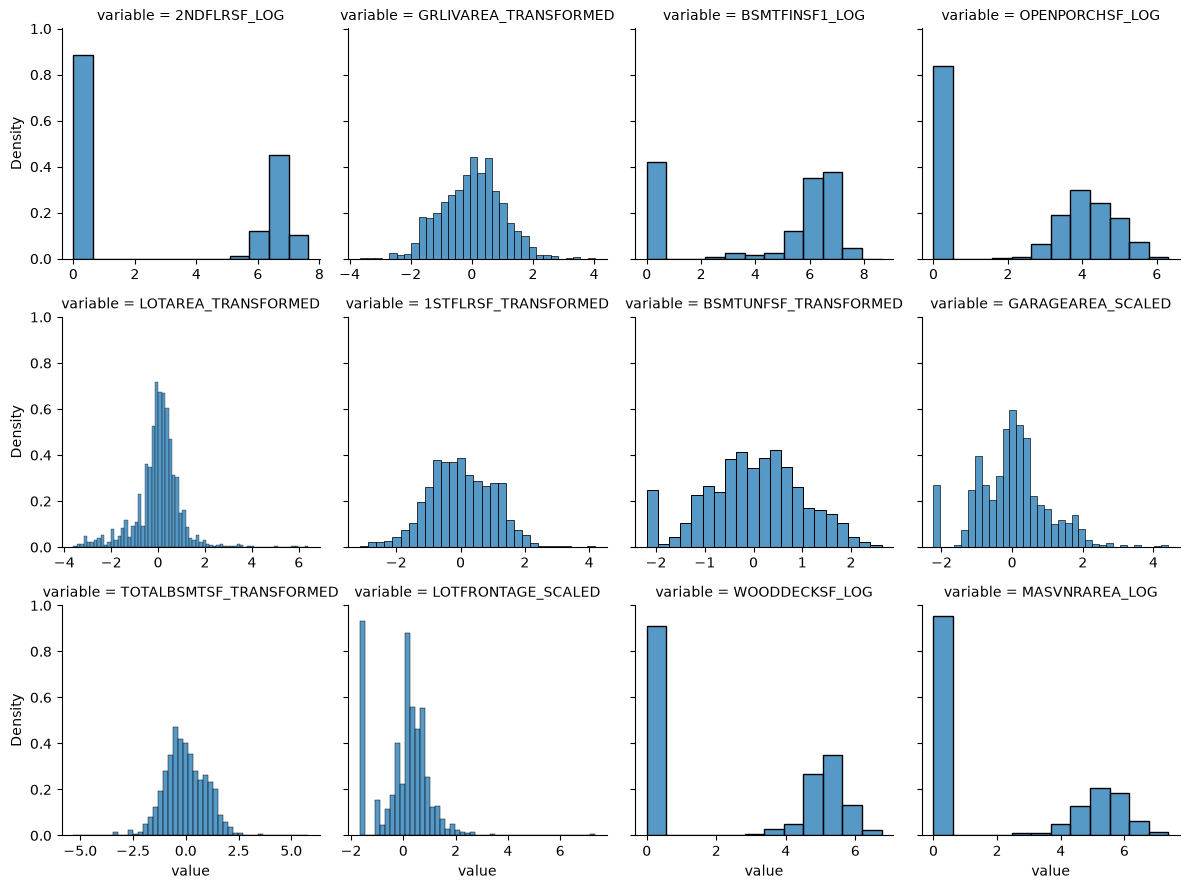

In [1083]:
# NUMERIC COLUMNS DISTRIBUTION
sns.FacetGrid(
    pd.melt(df_quant_cont, value_vars=quant_cont),
    col="variable", col_wrap=4, sharex=False, sharey=True, 
).map(sns.histplot, "value", stat="density")

## Qualitative nominal

In [1084]:
df_qual_nom = df_quant_cont.copy()

for col in qual_nom:
    print(df_qual_nom[col].value_counts().sort_index(ascending=False))
    print()


MSSUBCLASS
190     28
180     10
160     63
120     86
90      38
85      19
80      57
75      16
70      60
60     294
50     141
45      12
40       4
30      69
20     515
Name: count, dtype: int64

MSZONING
RM          214
RL         1111
RH           15
FV           62
C (ALL)      10
Name: count, dtype: int64

STREET
PAVE    1406
GRVL       6
Name: count, dtype: int64

ALLEY
PAVE      40
NA      1323
GRVL      49
Name: count, dtype: int64

LANDCONTOUR
LVL    1267
LOW      34
HLS      50
BNK      61
Name: count, dtype: int64

LOTCONFIG
INSIDE     1015
FR3           4
FR2          46
CULDSAC      91
CORNER      256
Name: count, dtype: int64

NEIGHBORHOOD
VEENKER     11
TIMBER      37
SWISU       25
STONEBR     25
SOMERST     83
SAWYERW     54
SAWYER      72
OLDTOWN    111
NWAMES      73
NRIDGHT     75
NPKVILL      9
NORIDGE     41
NAMES      215
MITCHEL     47
MEADOWV     17
IDOTRR      36
GILBERT     77
EDWARDS     89
CRAWFOR     50
COLLGCR    148
CLEARCR     27
BRKSIDE     55
BR

In [1085]:
for col in qual_nom:
    df_group_by_saleprice = df_qual_nom.groupby(col)['SALEPRICE'].agg(['mean', 'count'])
    df_group_by_saleprice.columns = df_group_by_saleprice.columns.str.upper()
    df_group_by_saleprice = df_group_by_saleprice.rename(columns={'MEAN':'SALEPRICE_MEAN'}) 
    df_group_by_saleprice['SALEPRICE_MEAN'] = df_group_by_saleprice['SALEPRICE_MEAN'].round(2)
    df_group_by_saleprice = df_group_by_saleprice.sort_values(by='SALEPRICE_MEAN', ascending=False)
    df_group_by_saleprice['PCT_COUNT'] = round((df_group_by_saleprice['COUNT'] / sum(df_group_by_saleprice['COUNT']))*100,2)
    df_group_by_saleprice['PCT_DIFF'] = df_group_by_saleprice['SALEPRICE_MEAN'].pct_change().round(2)*100
    df_group_by_saleprice['PCT_DIFF'] = df_group_by_saleprice['PCT_DIFF'].fillna(0)

    df_group_by_saleprice = df_group_by_saleprice[['SALEPRICE_MEAN', 'PCT_DIFF', 'COUNT', 'PCT_COUNT']]
    print(df_group_by_saleprice)
    print("\n", 50*"-", "\n")

            SALEPRICE_MEAN  PCT_DIFF  COUNT  PCT_COUNT
MSSUBCLASS                                            
60               240556.64       0.0    294      20.82
120              200789.30     -17.0     86       6.09
75               192437.50      -4.0     16       1.13
20               187178.59      -3.0    515      36.47
80               169775.79      -9.0     57       4.04
70               166772.42      -2.0     60       4.25
40               156125.00      -6.0      4       0.28
85               145142.11      -7.0     19       1.35
50               144132.60      -1.0    141       9.99
90               143254.24      -1.0     38       2.69
160              138647.38      -3.0     63       4.46
190              133112.50      -4.0     28       1.98
45               108591.67     -18.0     12       0.85
180              102300.00      -6.0     10       0.71
30                95829.72      -6.0     69       4.89

 -------------------------------------------------- 

          

In [1086]:
columns_to_drop = []
columns_to_add = []


# CONVERT TO BOOL
df_qual_nom = df_qual_nom.rename(columns={"CENTRALAIR": "HASCENTRALAIR"})
df_qual_nom['HASCENTRALAIR'] = np.where(df_qual_nom['HASCENTRALAIR']=='Y', 1, 0).astype('bool')
columns_to_drop.append("CENTRALAIR")
columns_to_add.append("HASCENTRALAIR")

df_qual_nom = df_qual_nom.rename(columns={"ALLEY": "HASALLEY"})
df_qual_nom['HASALLEY'] = np.where(df_qual_nom['HASALLEY']=='NA', 0, 1).astype('bool')
columns_to_drop.append("ALLEY")
columns_to_add.append("HASALLEY")

df_qual_nom = df_qual_nom.rename(columns={"STREET": "ISPAVED"})
df_qual_nom['ISPAVED'] = np.where(df_qual_nom['ISPAVED']=='PAVE', 1, 0).astype('bool')
columns_to_drop.append("STREET")
columns_to_add.append("ISPAVED")

df_qual_nom = df_qual_nom.rename(columns={"LANDCONTOUR": "FLATNESS"})
df_qual_nom["FLATNESS"] = df_qual_nom["FLATNESS"].map({'HLS': 2, 'LOW': 0, 'LVL': 1, 'BNK': 1})
columns_to_drop.append("LANDCONTOUR")
columns_to_add.append("FLATNESS")

# UPDATE QUAL_NOM
qual_nom = list((set(qual_nom) - set(columns_to_drop)))
qual_nom = list(set(qual_nom).union({"FLATNESS"}))
quant_bool = list(set(quant_bool).union({"HASCENTRALAIR", "HASALLEY", "ISPAVED"}))
